In [2]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from neural_net import RobotNet

no model found, using random weights


/home/prashanna/Documents/project_spatial_awarness/previous_model/neural_net.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model.pth

In [3]:
df = pd.read_csv('dataset.csv')

In [4]:
if "L" in df.columns:
    df = df.rename(columns={
        "L": "left_sensor", "F": "front_sensor", "R": "right_sensor",
        "vL": "left_motor", "vR": "right_motor"
    })

In [5]:
filtered_df = df.copy()

In [6]:
X = filtered_df[['left_sensor', 'front_sensor', 'right_sensor']].values
y = filtered_df[['left_motor', 'right_motor']].values

In [7]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
BATCH_SIZE = 64  # Small batch sizes generalize better for behavioral cloning
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [10]:
neuron = RobotNet()
criterion = nn.MSELoss()
optimizer = Adam(neuron.parameters(), lr=0.001)

In [11]:
epochs = 50  # With mini-batching, 50 epochs is plenty
train_losses = []
val_losses = []

In [12]:
for epoch in range(epochs):
    neuron.train()
    running_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Forward pass
        pred = neuron(batch_X)
        loss = criterion(pred, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
    
    # Calculate average epoch training loss
    epoch_train_loss = running_train_loss / len(X_train)
    train_losses.append(epoch_train_loss)

    neuron.eval()
    with torch.no_grad():
        test_pred = neuron(X_test)
        epoch_val_loss = criterion(test_pred, y_test).item()
        val_losses.append(epoch_val_loss)
    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:02d} | Train MSE: {epoch_train_loss:.5f} | Val MSE: {epoch_val_loss:.5f}")

Epoch 00 | Train MSE: 0.07769 | Val MSE: 0.04558
Epoch 05 | Train MSE: 0.02012 | Val MSE: 0.01885
Epoch 10 | Train MSE: 0.01608 | Val MSE: 0.01500
Epoch 15 | Train MSE: 0.01349 | Val MSE: 0.01460
Epoch 20 | Train MSE: 0.01165 | Val MSE: 0.01074
Epoch 25 | Train MSE: 0.01059 | Val MSE: 0.01001
Epoch 30 | Train MSE: 0.00960 | Val MSE: 0.01201
Epoch 35 | Train MSE: 0.00888 | Val MSE: 0.00990
Epoch 40 | Train MSE: 0.00821 | Val MSE: 0.00757
Epoch 45 | Train MSE: 0.00786 | Val MSE: 0.00901
Epoch 49 | Train MSE: 0.00742 | Val MSE: 0.00692


In [13]:
torch.save(neuron.state_dict(), "model.pth")
print("\nModel saved successfully as 'model.pth'.")


Model saved successfully as 'model.pth'.


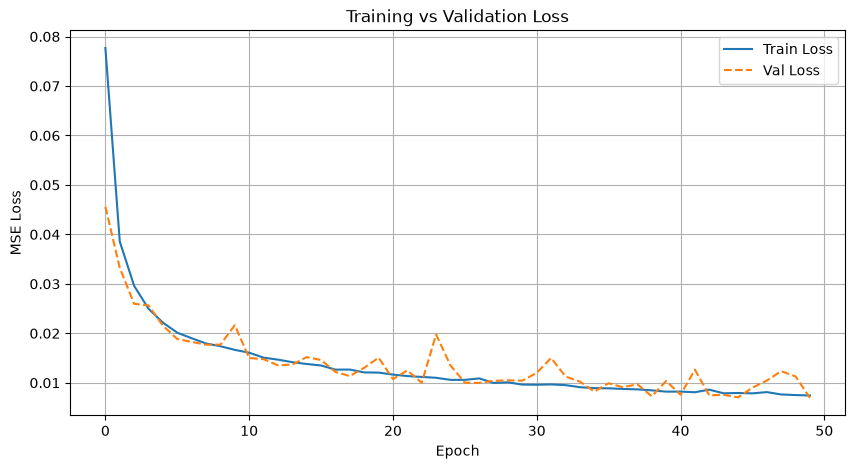

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
neuron.eval()
with torch.no_grad():
    train_pred = neuron(X_train)
    test_pred = neuron(X_test)
    
    train_left_mae = torch.mean(torch.abs(train_pred[:, 0] - y_train[:, 0]))
    train_right_mae = torch.mean(torch.abs(train_pred[:, 1] - y_train[:, 1]))
    test_left_mae = torch.mean(torch.abs(test_pred[:, 0] - y_test[:, 0]))
    test_right_mae = torch.mean(torch.abs(test_pred[:, 1] - y_test[:, 1]))

print("\n--- Final Performance Evaluation ---")
print(f"Train Left Motor MAE:  {train_left_mae.item():.4f}")
print(f"Train Right Motor MAE: {train_right_mae.item():.4f}")
print(f"Test Left Motor MAE:   {test_left_mae.item():.4f}")
print(f"Test Right Motor MAE:  {test_right_mae.item():.4f}")


--- Final Performance Evaluation ---
Train Left Motor MAE:  0.0394
Train Right Motor MAE: 0.0239
Test Left Motor MAE:   0.0398
Test Right Motor MAE:  0.0247
